Everything below focuses on visualization and biological interpretation.

```{important}
This section assumes you have already generated for all RBP datasets (using the `reproducibility/Fig7/data_preprocess.ipynb` notebook) and saved the following files:

- `results/reproducibility/gwas_resources/match_GWAS.csv`  
  BRIDGE variant scores merged with `gene_name` and GWAS `p_value`.

**Note:**

Running the full pipeline across all RBPs can be time-consuming.  
To make it easier to reproduce the figures directly, we also provide these precomputed files on `Figshare`.
```


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: sysfonts

Loading required package: showtextdb



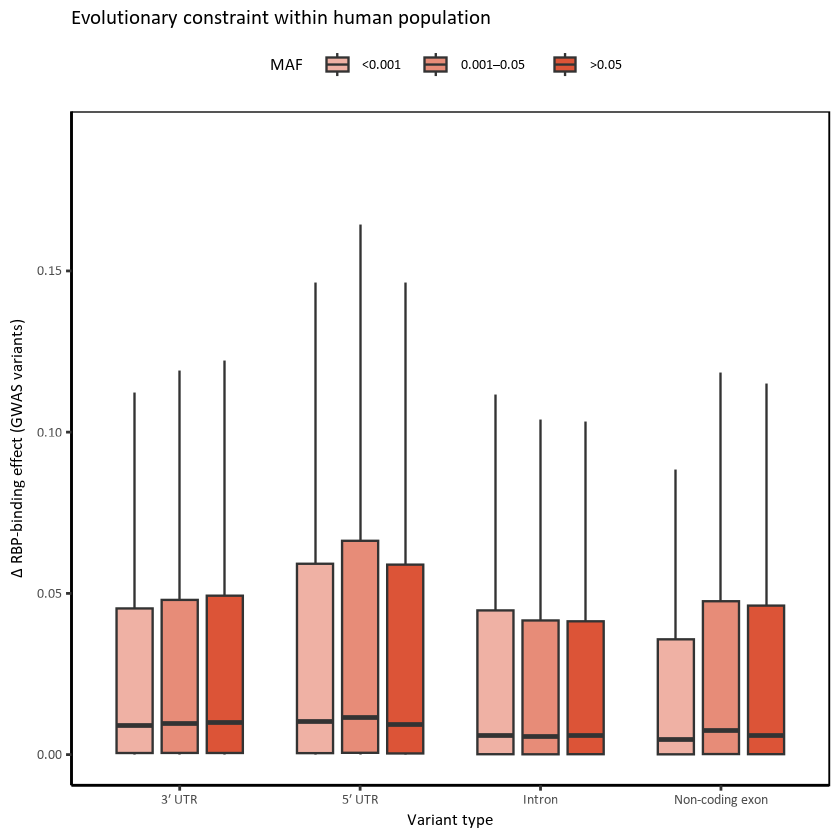

In [1]:
# ============================================================
# 0. Dependencies
# ============================================================
library(ggplot2)
library(dplyr)
library(readr)
library(showtext)     # Embed fonts in output (Calibri)

# ============================================================
# 1. Register & enable Calibri (update the path if needed)
# ============================================================
font_add(
  family  = "Calibri",
  regular = "/home/wangyubo/code/font/CALIBRI.TTF"
)
showtext_auto()

# ============================================================
# 2. Load and transform data (suppress column-type messages)
# ============================================================
# Logistic sigmoid; maps real-valued scores to (0, 1)
sigmoid <- function(x) plogis(x)

df <- read_csv(
  "../../results/reproducibility/gwas_resources/mutation_scores_with_gene.csv",
  show_col_types = FALSE
) %>%
  mutate(
    # Convert raw scores to probabilities
    alt_sigmoid = sigmoid(alt_score),
    ref_sigmoid = sigmoid(ref_score),

    # Absolute change in predicted effect between alt and ref alleles
    abs_diff    = abs(alt_sigmoid - ref_sigmoid),

    # Bin variants by minor allele frequency (MAF)
    MAF_group   = case_when(
      MAF < 0.001 ~ "<0.001",
      MAF > 0.05  ~ ">0.05",
      TRUE        ~ "0.001–0.05"
    ),

    # Map detailed region annotations to a small set of region categories
    region_type = case_when(
      grepl("3_prime_UTR",                region) ~ "3′ UTR",
      grepl("5_prime_UTR",                region) ~ "5′ UTR",
      grepl("intron_variant",             region) ~ "Intron",
      grepl("non_coding_transcript_exon", region) ~ "Non-coding exon",
      TRUE ~ NA_character_
    )
  ) %>%
  # Keep only variants that fall into the defined region categories
  filter(!is.na(region_type))

# Fix factor order so plotting follows a consistent, meaningful sequence
df$MAF_group   <- factor(df$MAF_group,   levels = c("<0.001", "0.001–0.05", ">0.05"))
df$region_type <- factor(df$region_type, levels = c("3′ UTR", "5′ UTR", "Intron", "Non-coding exon"))

# Manual palette for MAF bins (named vector so ggplot matches levels correctly)
fill_cols <- c(
  "<0.001"     = "#EFB1A4",
  "0.001–0.05" = "#E78C78",
  ">0.05"      = "#dc5437"
)

# ============================================================
# 3. Plot: boxplots of absolute effect change by region and MAF
#    (No p-values or statistical annotations)
# ============================================================
p <- ggplot(df, aes(x = region_type, y = abs_diff, fill = MAF_group)) +
  # Dodged boxplots to compare MAF bins within each region category
  geom_boxplot(
    outlier.shape = NA,
    width = 0.6,
    position = position_dodge(width = 0.75)
  ) +
  scale_fill_manual(values = fill_cols) +
  # Zoom the visible y-range without dropping data points
  coord_cartesian(ylim = c(0, 0.19)) +
  labs(
    x = "Variant type",
    y = "Δ RBP-binding effect (GWAS variants)",
    title = "Evolutionary constraint within human population",
    fill = "MAF"
  ) +
  theme_classic(base_size = 13, base_family = "Calibri") +
  theme(
    # axis.text.x = element_text(angle = 30, hjust = 1),  # uncomment if labels overlap
    legend.position    = "top",
    panel.grid.major.x = element_blank(),
    panel.border       = element_rect(colour = "black", fill = NA, linewidth = 0.5),
    axis.line          = element_line(colour = "black")
  )

print(p)


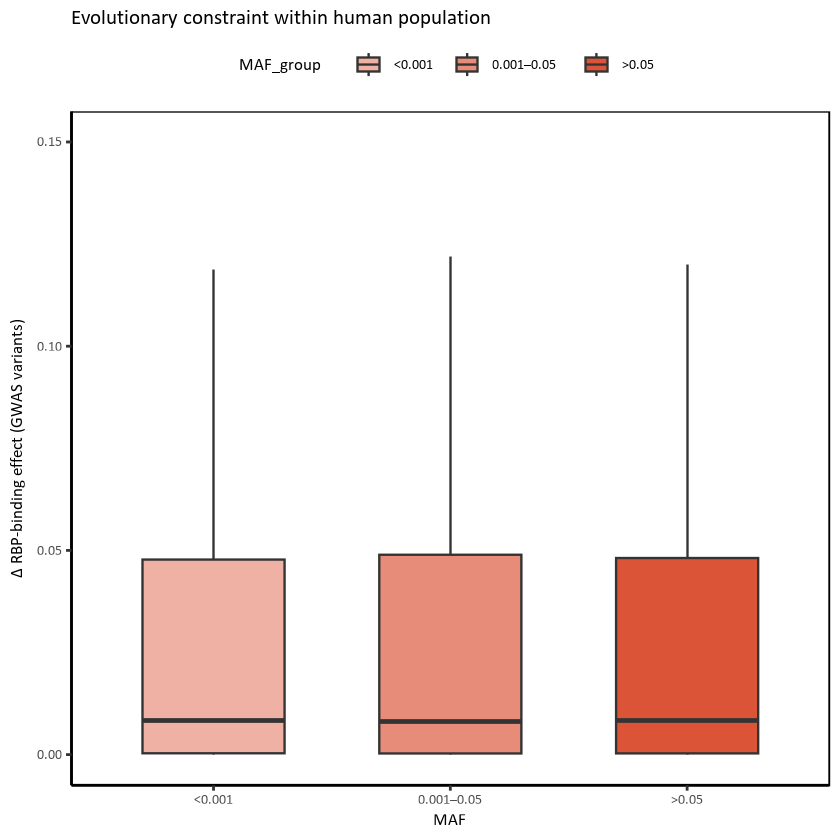

In [2]:
# ============================================================
# 0. Dependencies
# ============================================================
library(ggplot2)
library(dplyr)
library(readr)
library(showtext)     # Embed fonts in output (Calibri)

# ============================================================
# 1. Register & enable Calibri (make sure the path is correct)
# ============================================================
font_add(
  family  = "Calibri",
  regular = "/home/wangyubo/code/font/CALIBRI.TTF"
)
showtext_auto()

# ============================================================
# 2. Load and process data
# ============================================================
# Logistic sigmoid; maps real-valued scores to (0, 1)
sigmoid <- function(x) plogis(x)

df <- read_csv(
  "../../results/reproducibility/gwas_resources/mutation_scores_with_gene.csv",
  show_col_types = FALSE
) %>%
  mutate(
    # Convert raw scores to probabilities
    alt_sigmoid = sigmoid(alt_score),
    ref_sigmoid = sigmoid(ref_score),

    # Absolute change in predicted effect between alt and ref alleles
    abs_diff    = abs(alt_sigmoid - ref_sigmoid),

    # Bin variants by minor allele frequency (MAF)
    MAF_group   = case_when(
      MAF < 0.001 ~ "<0.001",
      MAF > 0.05  ~ ">0.05",
      TRUE        ~ "0.001–0.05"
    )
  )

# Fix factor order so plotting follows a consistent, meaningful sequence
df$MAF_group <- factor(df$MAF_group, levels = c("<0.001", "0.001–0.05", ">0.05"))

# Manual palette for MAF bins (named vector so ggplot matches levels correctly)
fill_cols <- c(
  "<0.001"     = "#EFB1A4",
  "0.001–0.05" = "#E78C78",
  ">0.05"      = "#dc5437"
)

# ============================================================
# 3. Plot: boxplots of absolute effect change by MAF
# ============================================================
p <- ggplot(df, aes(x = MAF_group, y = abs_diff, fill = MAF_group)) +
  geom_boxplot(outlier.shape = NA, width = 0.6) +
  scale_fill_manual(values = fill_cols) +
  # Zoom the visible y-range without dropping data points
  coord_cartesian(ylim = c(0, 0.15)) +
  labs(
    title = "Evolutionary constraint within human population",
    x     = "MAF",
    y     = "Δ RBP-binding effect (GWAS variants)"
  ) +
  theme_classic(base_size = 13, base_family = "Calibri") +
  theme(
    legend.position    = "top",
    panel.grid.major.x = element_blank(),
    panel.border       = element_rect(colour = "black", fill = NA, linewidth = 0.5),
    axis.line          = element_line(colour = "black")
  )

# In non-interactive scripts, explicitly print the ggplot object
print(p)
